In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.cm import rainbow
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [66]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [67]:
heart_diseases_data = pd.read_csv('./dataset/heart_diseases.csv')

In [68]:
heart_diseases_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [54]:
heart_diseases_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


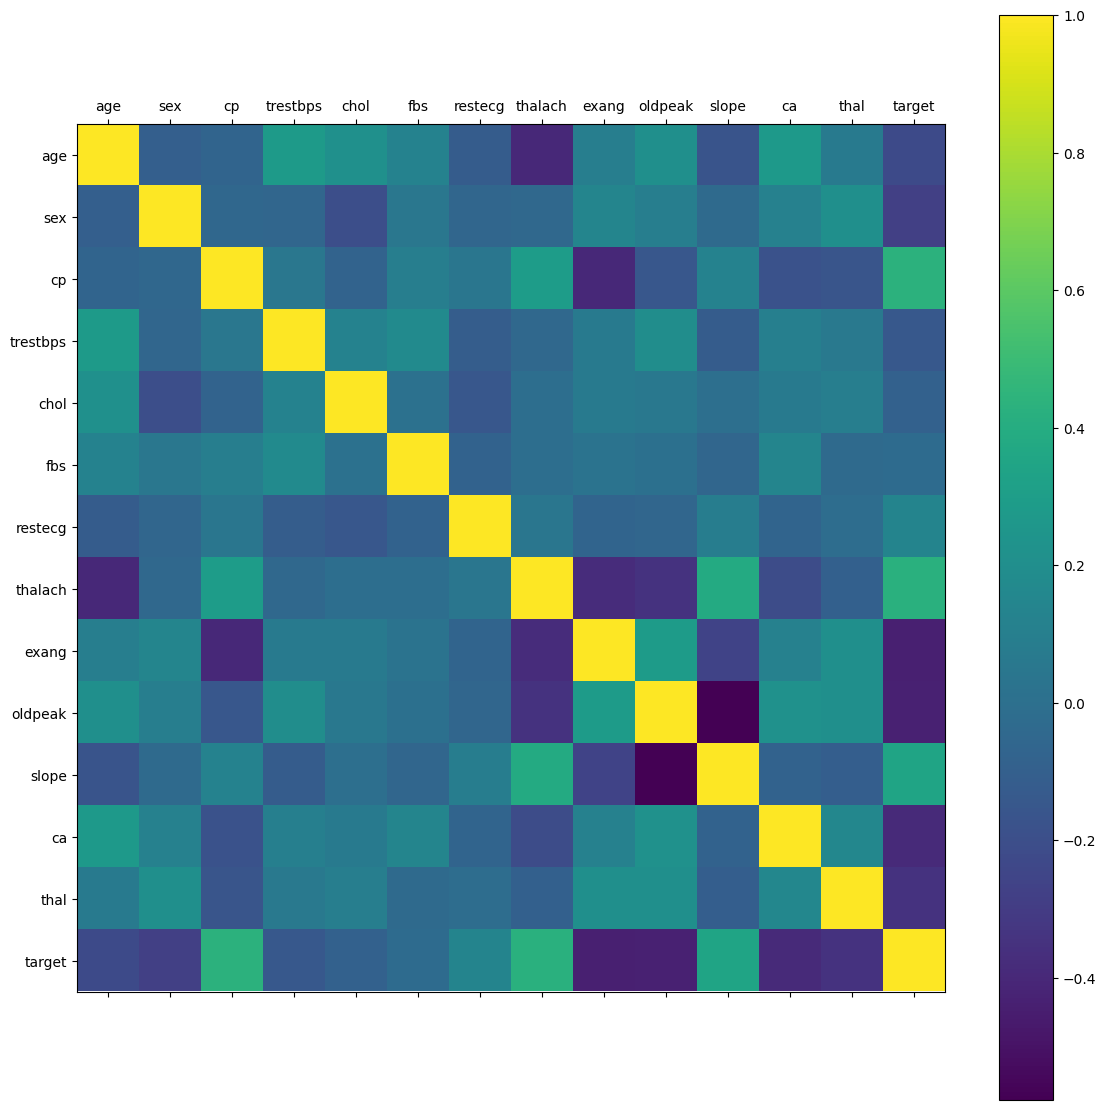

In [55]:
rcParams['figure.figsize'] = 20, 14
plt.matshow(heart_diseases_data.corr())
plt.yticks(np.arange(heart_diseases_data.shape[1]), heart_diseases_data.columns)
plt.xticks(np.arange(heart_diseases_data.shape[1]), heart_diseases_data.columns)
plt.colorbar()

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalach'}>],
       [<Axes: title={'center': 'exang'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

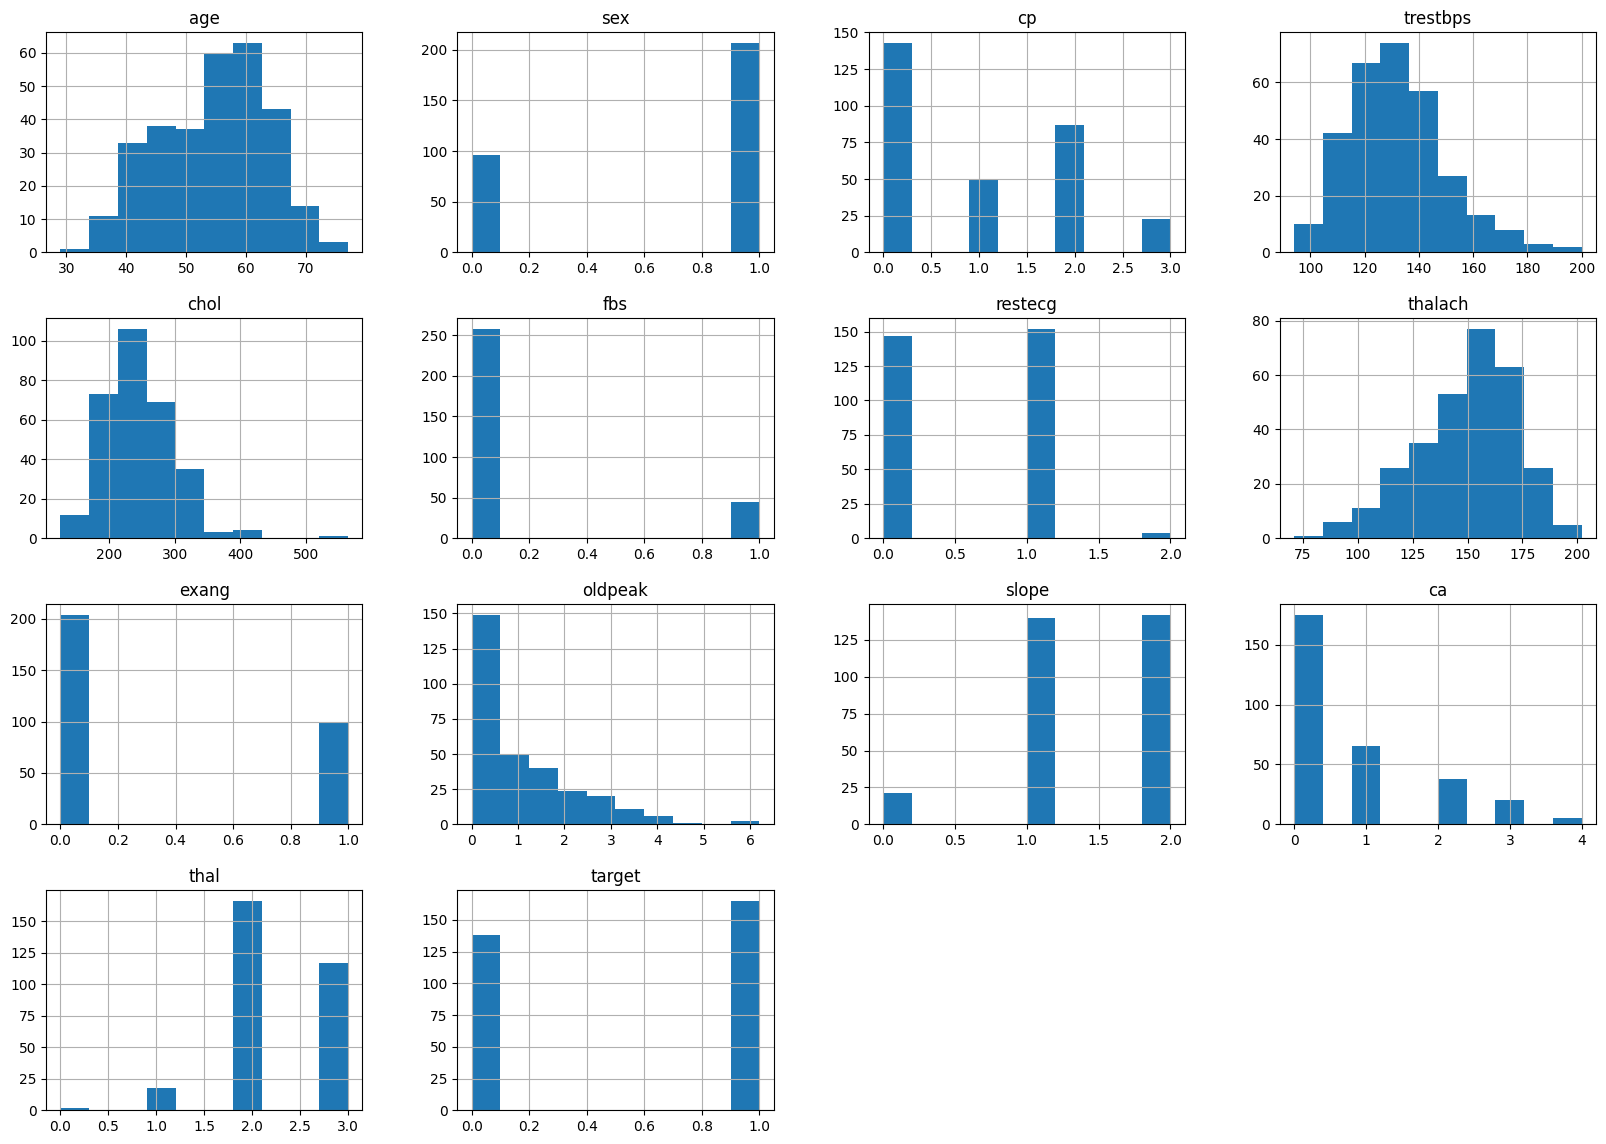

In [56]:
heart_diseases_data.hist()

In [57]:
 heart_diseases_data= pd.get_dummies(heart_diseases_data,columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal'])

In [20]:
standardScaler = StandardScaler()
columns_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
heart_diseases_data[columns_to_scale] = standardScaler.fit_transform(heart_diseases_data[columns_to_scale])

In [23]:
y = heart_diseases_data['target']
X = heart_diseases_data.drop(['target'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 0)

In [24]:
knn_scores = []
for k in range(1,21):
    knn_classifier = KNeighborsClassifier(n_neighbors = k)
    knn_classifier.fit(X_train, y_train)
    knn_scores.append(knn_classifier.score(X_test, y_test))

Text(0.5, 1.0, 'K Neighbors Classifier scores for different K values')

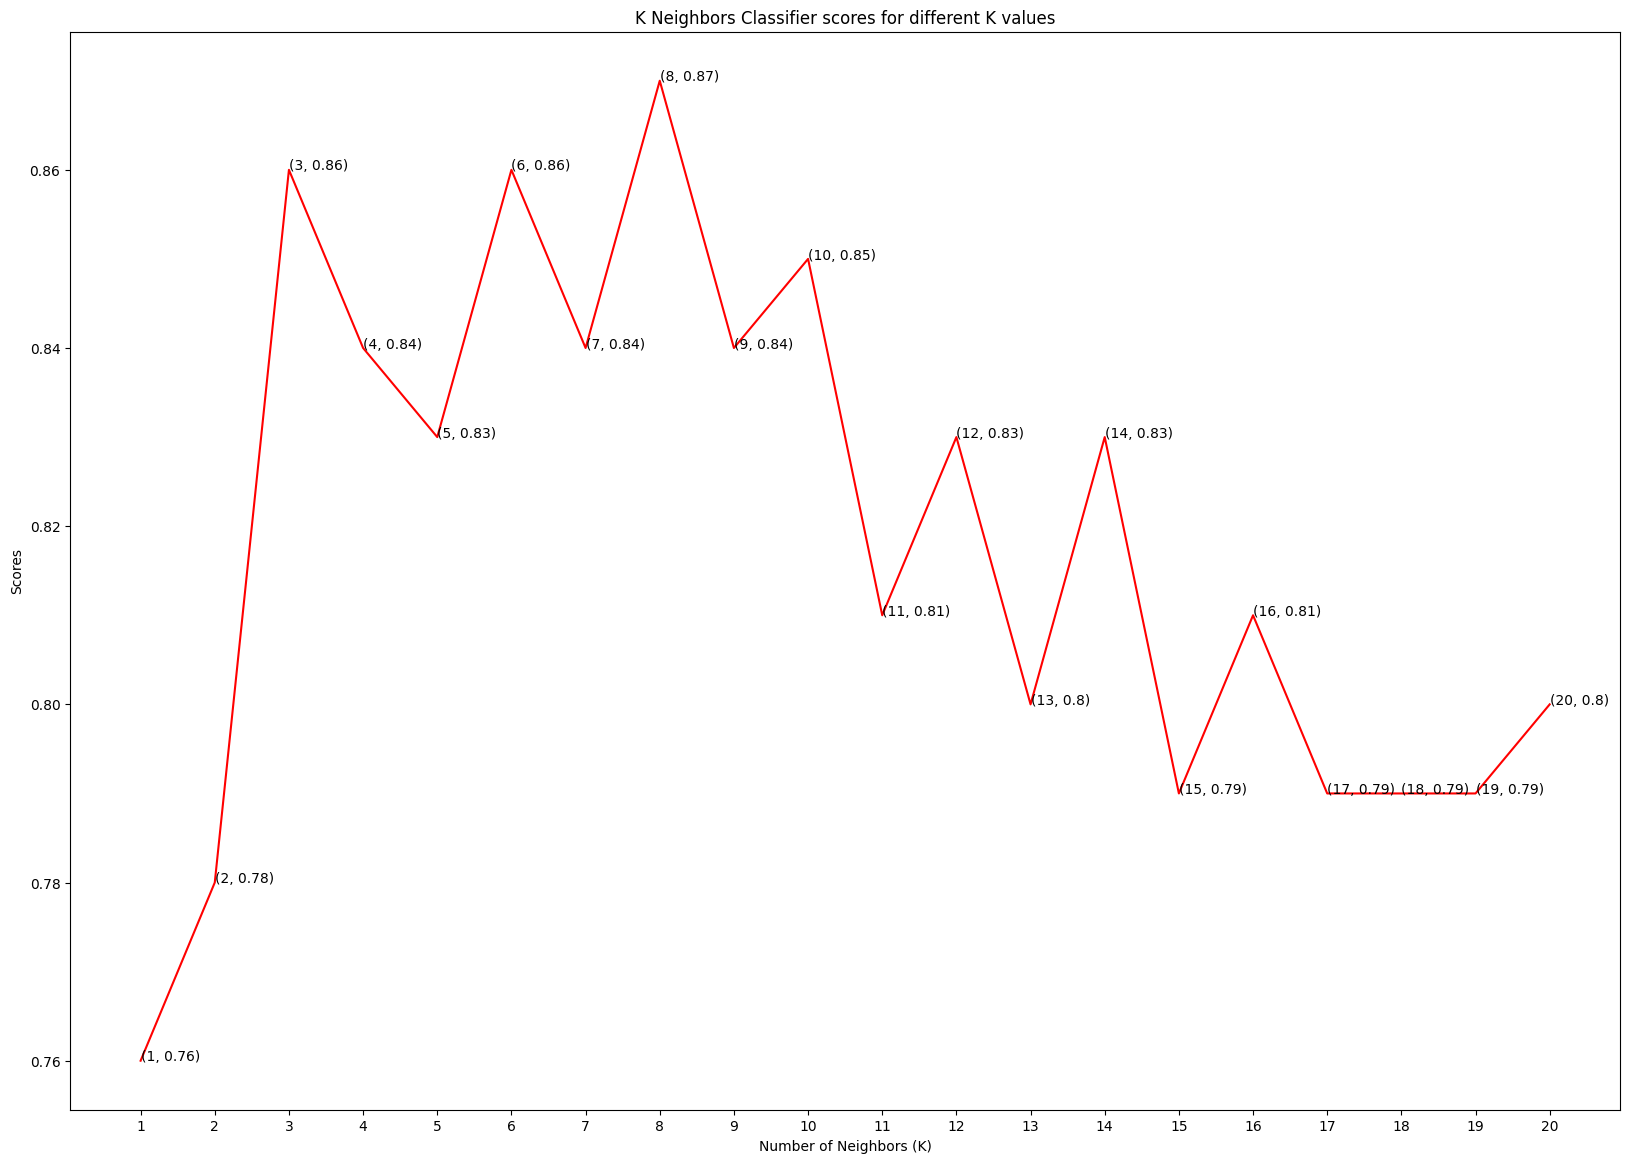

In [25]:
plt.plot([k for k in range(1, 21)], knn_scores, color = 'red')
for i in range(1,21):
    plt.text(i, knn_scores[i-1], (i, knn_scores[i-1]))
plt.xticks([i for i in range(1, 21)])
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Scores')
plt.title('K Neighbors Classifier scores for different K values')

In [26]:
print("The score for K Neighbors Classifier is {}% with {} nieghbors.".format(knn_scores[7]*100, 8))

The score for K Neighbors Classifier is 87.0% with 8 nieghbors.


In [31]:
svc_scores = []
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for i in range(len(kernels)):
    svc_classifier = SVC(kernel = kernels[i])
    svc_classifier.fit(X_train, y_train)
    svc_scores.append(svc_classifier.score(X_test, y_test))

In [32]:
print("The score for Support Vector Classifier is {}% with {} kernel.".format(svc_scores[0]*100, 'linear'))

The score for Support Vector Classifier is 83.0% with linear kernel.


In [33]:
dt_scores = []
for i in range(1, len(X.columns) + 1):
    dt_classifier = DecisionTreeClassifier(max_features = i, random_state = 0)
    dt_classifier.fit(X_train, y_train)
    dt_scores.append(dt_classifier.score(X_test, y_test))

Text(0.5, 1.0, 'Decision Tree Classifier scores for different number of maximum features')

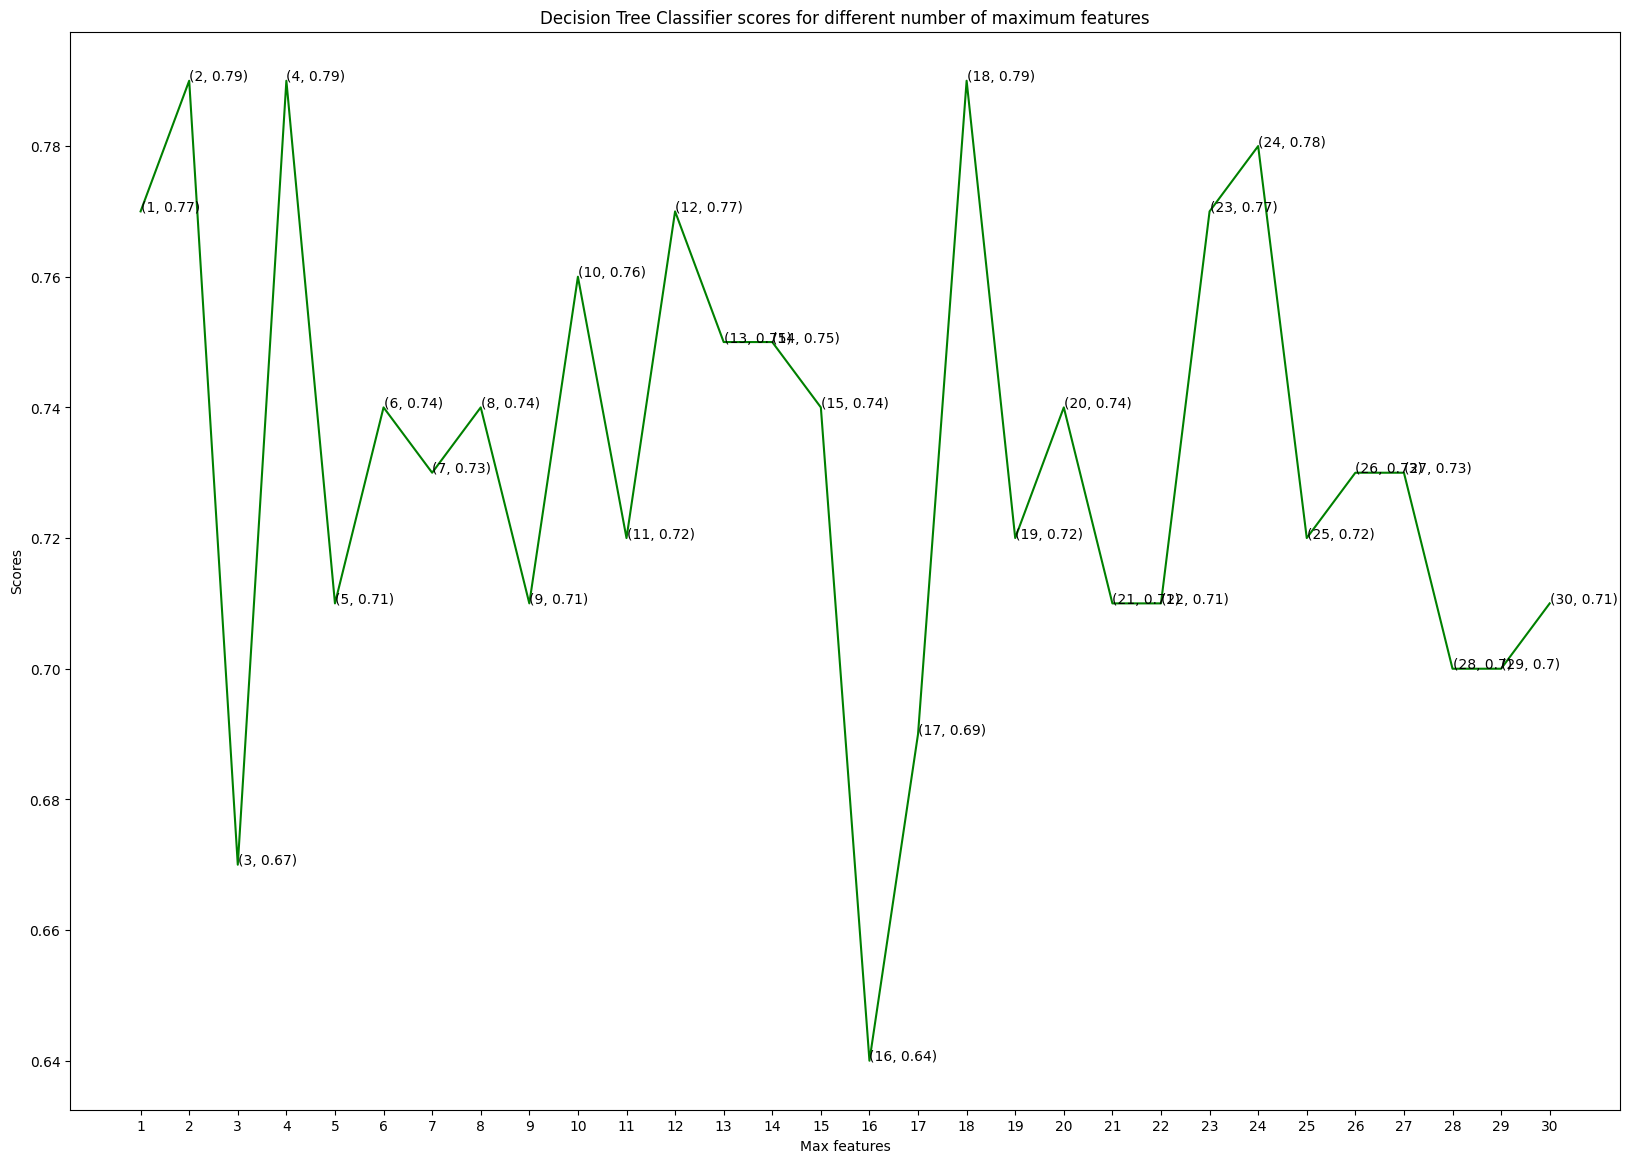

In [34]:
plt.plot([i for i in range(1, len(X.columns) + 1)], dt_scores, color = 'green')
for i in range(1, len(X.columns) + 1):
    plt.text(i, dt_scores[i-1], (i, dt_scores[i-1]))
plt.xticks([i for i in range(1, len(X.columns) + 1)])
plt.xlabel('Max features')
plt.ylabel('Scores')
plt.title('Decision Tree Classifier scores for different number of maximum features')

In [35]:
print("The score for Decision Tree Classifier is {}% with {} maximum features.".format(dt_scores[17]*100, [2,4,18]))

The score for Decision Tree Classifier is 79.0% with [2, 4, 18] maximum features.


In [36]:
rf_scores = []
estimators = [10, 100, 200, 500, 1000]
for i in estimators:
    rf_classifier = RandomForestClassifier(n_estimators = i, random_state = 0)
    rf_classifier.fit(X_train, y_train)
    rf_scores.append(rf_classifier.score(X_test, y_test))

Text(0.5, 1.0, 'Random Forest Classifier scores for different number of estimators')

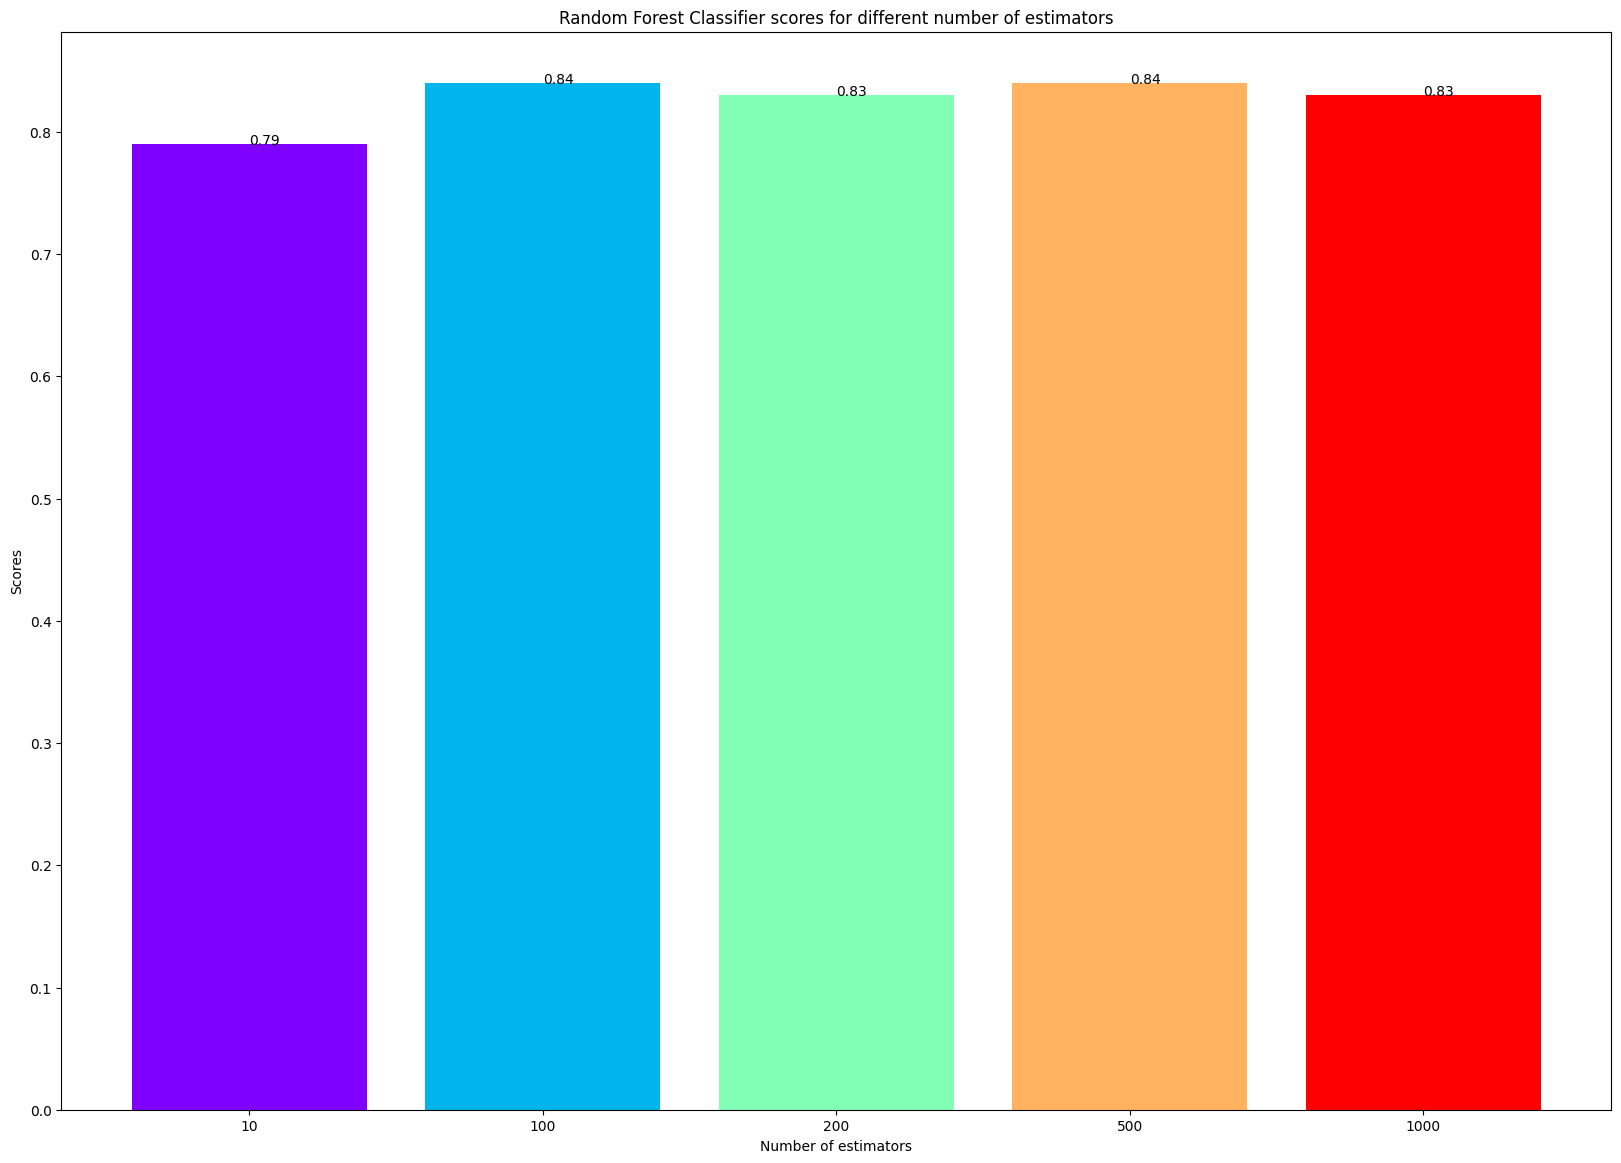

In [37]:
colors = rainbow(np.linspace(0, 1, len(estimators)))
plt.bar([i for i in range(len(estimators))], rf_scores, color = colors, width = 0.8)
for i in range(len(estimators)):
    plt.text(i, rf_scores[i], rf_scores[i])
plt.xticks(ticks = [i for i in range(len(estimators))], labels = [str(estimator) for estimator in estimators])
plt.xlabel('Number of estimators')
plt.ylabel('Scores')
plt.title('Random Forest Classifier scores for different number of estimators')

In [38]:
heart_diseases_data['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [ ]:
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']

In [39]:
print(X)

          age  trestbps      chol   thalach   oldpeak  sex_0  sex_1   cp_0  \
0    0.952197  0.763956 -0.256334  0.015443  1.087338  False   True  False   
1   -1.915313 -0.092738  0.072199  1.633471  2.122573  False   True  False   
2   -1.474158 -0.092738 -0.816773  0.977514  0.310912   True  False  False   
3    0.180175 -0.663867 -0.198357  1.239897 -0.206705  False   True  False   
4    0.290464 -0.663867  2.082050  0.583939 -0.379244   True  False   True   
..        ...       ...       ...       ...       ...    ...    ...    ...   
298  0.290464  0.478391 -0.101730 -1.165281 -0.724323   True  False   True   
299 -1.033002 -1.234996  0.342756 -0.771706  0.138373  False   True  False   
300  1.503641  0.706843 -1.029353 -0.378132  2.036303  False   True   True   
301  0.290464 -0.092738 -2.227533 -1.515125  0.138373  False   True   True   
302  0.290464 -0.092738 -0.198357  1.064975 -0.896862   True  False  False   

      cp_1   cp_2  ...  slope_2   ca_0   ca_1   ca_2   ca_3   c

In [42]:
print(y)

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64


In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2)

In [46]:
print(X.shape, X_train.shape, X_test.shape)

(303, 30) (242, 30) (61, 30)


In [59]:
model = LogisticRegression()

In [60]:
model.fit(X_train, y_train)

LogisticRegression()

In [70]:
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, y_train)

In [71]:
print('Accuracy on Training data : ', training_data_accuracy)

Accuracy on Training data :  0.8842975206611571


In [72]:
input_data = (56,1,1,120,236,0,1,178,0,0.8,2,0,2)

In [73]:
input_data_as_numpy_array= np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
prediction = model.predict(input_data_reshaped)
print(prediction)
if (prediction[0]== 0):
    print('The Person does not have a Heart Disease')
else:
    print('The Person has Heart Disease')

ValueError: X has 13 features, but LogisticRegression is expecting 30 features as input.

In [74]:
print(accuracy_score(y_test, model.predict(X_test))*100)

83.60655737704919


In [75]:
import pickle

In [76]:
filename = 'heart_diseases_model.sav'
pickle.dump(model, open(filename, 'wb'))

In [77]:
load_model=pickle.load(open('heart_diseases_model.sav','rb'))

In [78]:
for column in X_test.columns:
  print(column)

age
trestbps
chol
thalach
oldpeak
sex_0
sex_1
cp_0
cp_1
cp_2
cp_3
fbs_0
fbs_1
restecg_0
restecg_1
restecg_2
exang_0
exang_1
slope_0
slope_1
slope_2
ca_0
ca_1
ca_2
ca_3
ca_4
thal_0
thal_1
thal_2
thal_3


In [79]:
import sklearn
print(sklearn.__version__)

1.6.1
